## Przygotowanie danych hoteli

Wczytujemy hotele z przypisanymi klastrami i wybieramy informacje potrzebne do wyszukiwania oraz tworzenia rekomendacji.

In [1]:
import pandas as pd

In [2]:
df_full = pd.read_csv('data/full/hotels_with_clusters.csv', encoding="utf-8")
df_full.head(1)

,location_id,address_obj.state,name_details,latitude,longitude,rating,num_reviews,photo_count,price_level,amenities,...,ranking_ratio,price_level_num,bad_review_share,excellent_review_share,location_rating,rooms_rating,service_rating,value_rating,cleanliness_rating,subratings_confidence
0,278399,Podlaskie Province,Hotel Cristal Bialystok,53.132675,23.15599,4.5,390,221,$,"['Internet', 'Suites', 'Room service', 'Free I...",...,0.0625,1.0,0.015385,0.587179,4.8,4.3,4.7,4.3,4.6,0.5


In [3]:
df = df_full[
    [
        "location_id",
        "name_details",
        "address_obj.city_details",
        "rating",
        "price_level",
        "amenities",
        "styles",
        "description",
    ]
].copy()

df["amenities"] = df["amenities"].fillna("")
df["styles"] = df["styles"].fillna("")
df["description"] = df["description"].fillna("")

df["text"] = (
    df["name_details"].fillna("").astype(str) + " " +
    df["address_obj.city_details"].fillna("").astype(str) + " " +
    df["description"].fillna("").astype(str) + " " +
    df["amenities"].fillna("").astype(str) + " " +
    df["styles"].fillna("").astype(str)
)

df.head(2)

,location_id,name_details,address_obj.city_details,rating,price_level,amenities,styles,description,text
0,278399,Hotel Cristal Bialystok,Bialystok,4.5,$,"['Internet', 'Suites', 'Room service', 'Free I...","['Modern', 'Classic']",,Hotel Cristal Bialystok Bialystok ['Internet'...
1,10050636,Ibis Styles Bialystok,Bialystok,4.5,$,"['Internet', 'Kids Activities', 'Suites', 'Roo...","['Modern', 'Mid-range']",,"Ibis Styles Bialystok Bialystok ['Internet', ..."


## Reprezentacja tekstowa

Opis każdego hotelu zamieniamy na wektor TF-IDF. Pozwala to porównywać obiekty na podstawie podobieństwa ich cech tekstowych.

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

texts = df['text'].tolist()

vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    max_features=30000,
    min_df=1,
    sublinear_tf=True,
    stop_words='english'
)

X = vectorizer.fit_transform(texts)

print(X.shape)

(135, 9234)


## Rekomendacje i wyszukiwanie

Podobieństwo cosinusowe służy do wskazywania hoteli podobnych do wybranego obiektu oraz do wyszukiwania hoteli pasujących do podanego zapytania.

In [5]:
from sklearn.metrics.pairwise import cosine_similarity

def hotel_recommendation(location_id, k = 5):
    idx_list = df.index[df['location_id'] == location_id].tolist()

    idx = idx_list[0]
    scores = cosine_similarity(X[idx], X).flatten()
    best = scores.argsort()[::-1]

    recommendations = []

    for i in best:
        if i == idx:
            continue
        recommendations.append({
            "location_id": int(df.iloc[i]["location_id"]),
            "name": df.iloc[i]["name_details"],
            "score": float(scores[i]),
            "description": df.iloc[i]["description"][:300],
            "amenities": df.iloc[i]["amenities"],
            "styles": df.iloc[i]["styles"],
        })

        if len(recommendations) == k:
            break

    return recommendations

In [6]:
def search_hotels(query, k = 5):
    q = vectorizer.transform([query])
    scores = cosine_similarity(q, X).flatten()

    best = scores.argsort()[::-1][:k]
    
    results = []

    for i in best:
        results.append({
            "location_id": int(df.iloc[i]["location_id"]),
            "name": df.iloc[i]["name_details"],
            "score": float(scores[i]),
            "description": df.iloc[i]["description"][:300],
            "amenities": df.iloc[i]["amenities"],
            "styles": df.iloc[i]["styles"],
        })
    return results

In [7]:
import numpy as np

df = df.replace({np.nan: None})

hotels_metadata = df[
    [
        "location_id",
        "name_details",
        "address_obj.city_details",
        "rating",
        "price_level",
        "description",
        "amenities",
        "styles",
    ]
].to_dict(orient="records")

import joblib
from pathlib import Path

MODEL_DIR = Path("models/tf_idf")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

index_data = {
    "vectorizer": vectorizer,
    "matrix": X,
    "hotels": hotels_metadata,
}

joblib.dump(index_data, MODEL_DIR / "tfidf_index.joblib")
print(f"Zapisano indeks TF-IDF: {MODEL_DIR}/tfidf_index.joblib")


Zapisano indeks TF-IDF: models\tf_idf/tfidf_index.joblib


## Precision @5

In [8]:
def parse_set(value):
    if pd.isna(value):
        return set()

    return {
        x.strip().lower()
        for x in str(value).split(",")
        if x.strip()
    }

In [9]:
def is_relevant(source_row, rec_row,
                min_amenities=2,
                min_styles=1,
                mode="or"):

    source_amenities = parse_set(source_row["amenities"])
    rec_amenities = parse_set(rec_row["amenities"])

    source_styles = parse_set(source_row["styles"])
    rec_styles = parse_set(rec_row["styles"])

    amenities_overlap = len(
        source_amenities & rec_amenities
    )

    styles_overlap = len(
        source_styles & rec_styles
    )

    amenities_ok = amenities_overlap >= min_amenities
    styles_ok = styles_overlap >= min_styles

    if mode == "amenities":
        return amenities_ok

    elif mode == "styles":
        return styles_ok

    elif mode == "and":
        return amenities_ok and styles_ok

    else:  # mode == "or"
        return amenities_ok or styles_ok

In [10]:
tests = [
    (1, 1),
    (2, 1),
    (2, 2),
    (3, 1),
    (3, 2),
    (3, 3),
    (4, 1),
    (4, 2),
    (4, 3),
    (4, 4),
]

In [11]:
def evaluate_precision(mode,
                       min_amenities=2,
                       min_styles=1):

    precisions = []

    for location_id in df["location_id"]:

        source_row = df[
            df["location_id"] == location_id
        ].iloc[0]

        recommendations = hotel_recommendation(
            location_id,
            k=5
        )

        hits = 0

        for rec in recommendations:

            rec_row = df[
                df["location_id"] == rec["location_id"]
            ].iloc[0]

            if is_relevant(
                source_row,
                rec_row,
                min_amenities=min_amenities,
                min_styles=min_styles,
                mode=mode
            ):
                hits += 1

        precisions.append(hits / 5)

    return np.mean(precisions)

In [12]:
test_results = []

modes = ["amenities", "styles", "or", "and"]

for mode in modes:
    for min_amenities in range(1, 4):
        for min_styles in range(1, 4):

            precision = evaluate_precision(
                mode=mode,
                min_amenities=min_amenities,
                min_styles=min_styles
            )

            test_results.append({
                "mode": mode,
                "min_amenities": min_amenities,
                "min_styles": min_styles,
                "precision_at_5": precision
            })

results_df = pd.DataFrame(test_results)

results_df

,mode,min_amenities,min_styles,precision_at_5
0,amenities,1,1,0.909630
1,amenities,1,2,0.909630
2,amenities,1,3,0.909630
3,amenities,2,1,0.891852
4,amenities,2,2,0.891852
5,amenities,2,3,0.891852
6,amenities,3,1,0.891852
7,amenities,3,2,0.891852
8,amenities,3,3,0.891852
9,styles,1,1,0.271111


In [13]:
results_df["config"] = (
    "A≥" + results_df["min_amenities"].astype(str)
    + ", S≥" +
    results_df["min_styles"].astype(str)
)

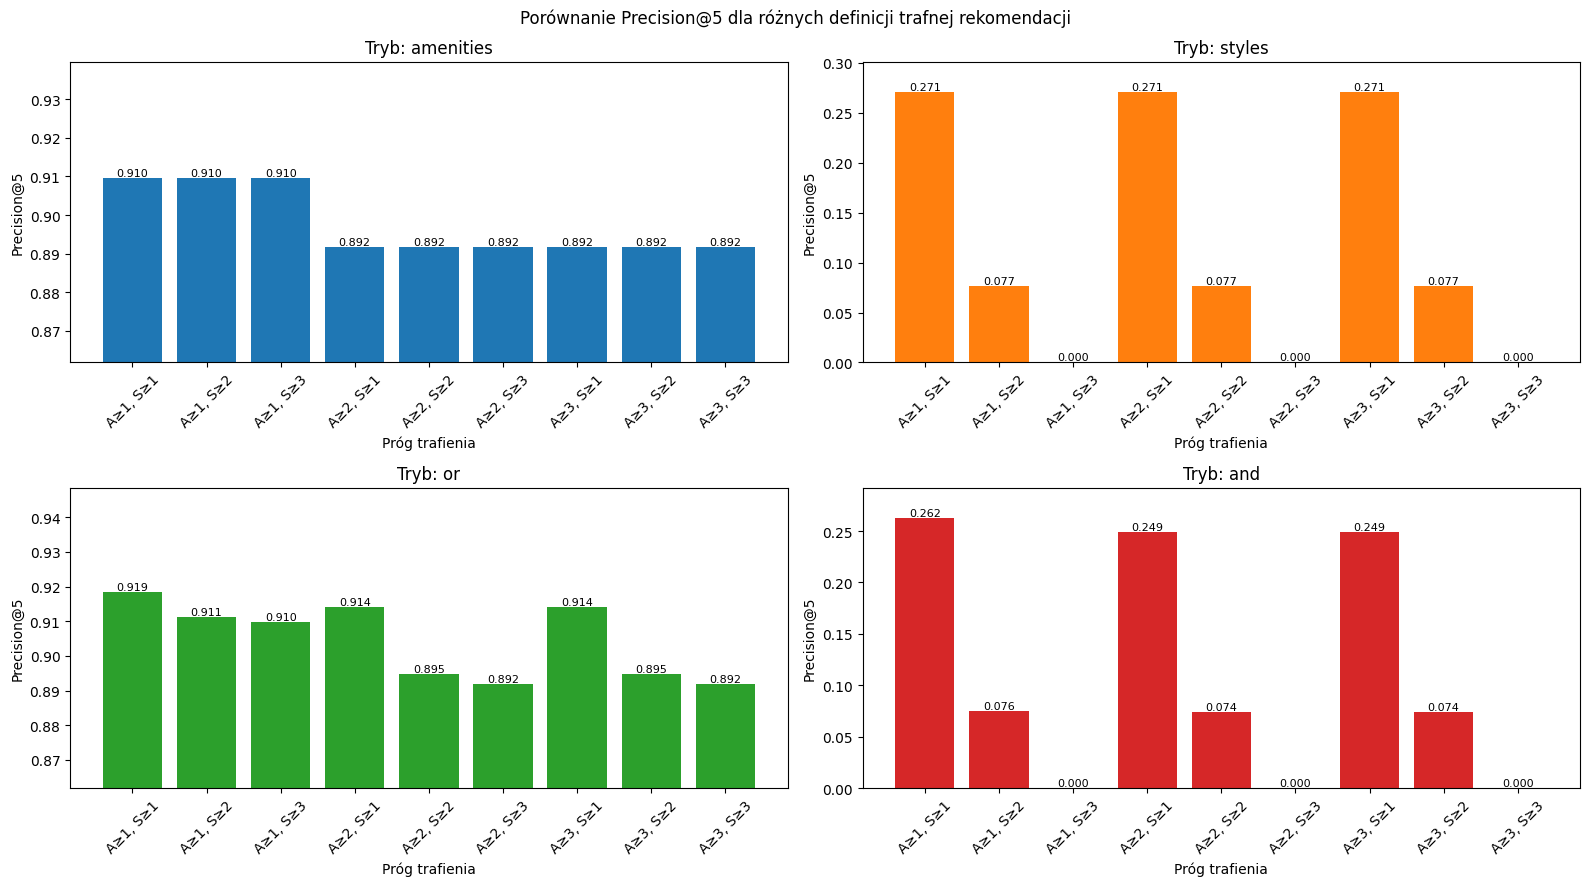

In [15]:
import matplotlib.pyplot as plt

colors = {
    "amenities": "tab:blue",
    "styles": "tab:orange",
    "or": "tab:green",
    "and": "tab:red"
}

if "threshold" not in results_df.columns:
    results_df["threshold"] = (
        "A≥" + results_df["min_amenities"].astype(str)
        + ", S≥" +
        results_df["min_styles"].astype(str)
    )

fig, axes = plt.subplots(2, 2, figsize=(16, 9))

modes = ["amenities", "styles", "or", "and"]
axes = axes.flatten()

for ax, mode in zip(axes, modes):

    mode_df = results_df[results_df["mode"] == mode]

    ax.bar(
        mode_df["threshold"],
        mode_df["precision_at_5"],
        color=colors[mode]
    )

    min_y = max(0, mode_df["precision_at_5"].min() - 0.03)
    max_y = min(1, mode_df["precision_at_5"].max() + 0.03)

    ax.set_ylim(min_y, max_y)

    ax.set_title(f"Tryb: {mode}")
    ax.set_xlabel("Próg trafienia")
    ax.set_ylabel("Precision@5")
    ax.tick_params(axis="x", rotation=45)

    for i, value in enumerate(mode_df["precision_at_5"]):
        ax.text(
            i,
            value,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.suptitle("Porównanie Precision@5 dla różnych definicji trafnej rekomendacji")
plt.tight_layout()
plt.show()